### Импорт библиотек и параметры

Импорт библиотек

In [ ]:
!pip install python-docx
!pip install -U transformers
!pip install -q trl bert-score openai
!pip uninstall -y trl
!pip install trl==0.11.3
!pip install -q accelerate>=1.8.0
!pip install -q bitsandbytes>=0.46.1

import time
import random
import re
import pandas as pd
from docx import Document
import numpy as np
from datasets import Dataset
import os
import json

import torch
torch.cuda.empty_cache()

import torch
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead
from transformers import AutoTokenizer, BitsAndBytesConfig
from bert_score import BERTScorer
import openai
from datasets import Dataset
import numpy as np
import gc
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 113.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.5 MB/s eta 0:00:00
Found existing installation: trl 1.2.0
Uninstalling trl-1.2.0:
  Successfully uninstalled trl-1.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 23.8 MB/s eta 0:00:00


Настройки API и других параметров лосса

In [ ]:
USE_LLM_REWARD = True
OPENROUTER_API_KEY = "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"
JUDGE_MODEL = "openai/gpt-oss-120b:free"
LLM_CALL_EVERY_N_STEPS = 1
EPOCHS_NUM = 3
MODEL_TO_LEARN = "Qwen/Qwen2.5-3B-Instruct"
LLM_MAX_RETRIES = 5
LLM_BASE_DELAY = 1.0
last_llm_score = 0.0

bertscorer = BERTScorer(lang="ru", rescale_with_baseline=False, device='cpu')

# Клиент OpenRouter
if USE_LLM_REWARD:
    openrouter_client = openai.OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY,
        default_headers={"Content-Type": "application/json; charset=utf-8"}
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def set_random_seed(seed: int = 27):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

set_random_seed()

### Преобразование данных для обучения

Чтение транскриптов и кодировок, сохранение в одной таблице

In [ ]:
def parse_pul_intervyu(filename):
    doc = Document(filename)
    paragraphs = [para.text.strip() for para in doc.paragraphs if para.text.strip()]
    if not paragraphs:
        return []

    global_topic = ""
    if not re.match(r'^Интервью\s+\d+', paragraphs[0]):
        global_topic = paragraphs[0]

    interviews = []
    current_interview = None
    in_transcript = False

    for text in paragraphs:
        if text == global_topic:
            continue
        match = re.match(r'^Интервью\s+(\d+)', text)
        if match:
            if current_interview:
                interviews.append(current_interview)
            interview_num = match.group(1)
            current_interview = {'interview_num': interview_num, 'topic': global_topic, 'transcript': ''}
            in_transcript = True
        elif current_interview and in_transcript:
            if current_interview['transcript']:
                current_interview['transcript'] += '\n' + text
            else:
                current_interview['transcript'] = text
    if current_interview:
        interviews.append(current_interview)
    return interviews

def parse_kodirovki(filename):
    doc = Document(filename)
    paragraphs = [para.text.strip() for para in doc.paragraphs if para.text.strip()]
    interviews = []
    current_interview = None
    for text in paragraphs:
        match = re.match(r'^Интервью\s+(\d+)', text)
        if match:
            if current_interview:
                interviews.append(current_interview)
            interview_num = match.group(1)
            current_interview = {'interview_num': interview_num, 'coding_text': ''}
        elif current_interview:
            if current_interview['coding_text']:
                current_interview['coding_text'] += '\n' + text
            else:
                current_interview['coding_text'] = text
    if current_interview:
        interviews.append(current_interview)
    return interviews

files = [
    ('pul_intervyu_1.docx', 'kodirovki_pfi_2023.docx', 'result1.xlsx'),
    ('pul_intervyu_2.docx', 'kodirovki_pfi_2024.docx', 'result2.xlsx'),
    ('pul_intervyu_3.docx', 'kodirovki_sp_2024.docx', 'result3.xlsx'),
    ('pul_intervyu_4.docx', 'kodirovki_pfi_2025.docx', 'result4.xlsx')
]

all_dfs = []
for trans_file, code_file, out_file in files:
    data1 = parse_pul_intervyu(trans_file)
    data2 = parse_kodirovki(code_file)
    df1 = pd.DataFrame(data1)
    df2 = pd.DataFrame(data2)
    merged = pd.merge(df1, df2, on='interview_num', how='outer')
    merged['sort_key'] = merged['interview_num'].apply(lambda x: int(x) if str(x).isdigit() else 0)
    merged = merged.sort_values('sort_key').drop('sort_key', axis=1).fillna('')

    result = merged[['topic', 'interview_num', 'transcript', 'coding_text']].copy()
    result.insert(0, 'Индекс', range(len(result)))
    result.columns = ['Индекс','Тема интервью', 'Порядковый номер интервью', 'Транскрипт интервью', 'Кодирование интервью']
    result.to_excel(out_file, index=False)
    all_dfs.append(result)
    print(result.head())

full_dataset = pd.concat(all_dfs, ignore_index=True)
full_dataset.insert(0, 'Общий номер', range(len(full_dataset)))
full_dataset.to_excel('full_interviews_dataset.xlsx', index=False)
print(f"Общий датасет: {len(full_dataset)} интервью")

    Индекс                                      Тема интервью  \
0        0  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   
11       1  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   
22       2  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   
23       3  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   
24       4  Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...   

   Порядковый номер интервью  \
0                          1   
11                         2   
22                         3   
23                         4   
24                         5   

                                  Транскрипт интервью  \
0   Интервьюер: Так, все, все записи начались. Сна...   
11  Интервьюер: Смотри, вначале расскажи, пожалуйс...   
22  Интервьюер: Так, тогда начинаем. Расскажи спер...   
23  Интервьюер: Тогда, наверное, начнем. Сперва мо...   
24  Интервьюер: Для начала расскажи о себе. Скольк...   

                                 Кодирование интервью  
0   **Общий код 1

Извлечение кодировок для обучающего датасета

In [ ]:
def extract_general_codes(coding_text):
    if pd.isna(coding_text) or not coding_text.strip():
        return []
    pattern = r'\*\*Общий код \d+:[^**]+\*\*'
    general_codes = re.findall(pattern, coding_text)
    general_codes = [code[2:-2].strip() for code in general_codes]
    return general_codes

def prepare_training_data(full_df):
    training_data = []
    for _, row in full_df.iterrows():
        if pd.notna(row['Кодирование интервью']) and row['Кодирование интервью'].strip():
            training_data.append({
                'id': row['Общий номер'],
                'task': 'code_generation',
                'input_text': f"{row['Тема интервью']}\n\nТранскрипт: {row['Транскрипт интервью']}",
                'target': row['Кодирование интервью']
            })
            general_codes = extract_general_codes(row['Кодирование интервью'])
            if general_codes:
                codes_list = "; ".join(general_codes)
                training_data.append({
                    'id': row['Общий номер'],
                    'task': 'text_markup_with_codes',
                    'input_text': f"Тема: {row['Тема интервью']}\nТранскрипт: {row['Транскрипт интервью']}\nОбщие коды: {codes_list}",
                    'target': row['Кодирование интервью']
                })
    return pd.DataFrame(training_data)

data = prepare_training_data(full_dataset)
data = data[data['task']=='code_generation']
data.head()

,id,task,input_text,target
0,0,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."
2,1,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."
4,2,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."
6,3,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."
8,4,code_generation,"Тема: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫ...","**Общий код 1: Поколенческие характеристики, ц..."


Разделение на train, val, test по ID интервью

In [ ]:
def split_dataset_properly(train_df):
    if 'id' not in train_df.columns:
        return None, None, None
    interview_ids = train_df['id'].unique()
    np.random.shuffle(interview_ids)
    n_train = int(0.7 * len(interview_ids))
    n_val = int(0.15 * len(interview_ids))
    train_ids = interview_ids[:n_train]
    val_ids = interview_ids[n_train:n_train+n_val]
    test_ids = interview_ids[n_train+n_val:]

    train_df_split = train_df[train_df['id'].isin(train_ids)].copy()
    val_df_split = train_df[train_df['id'].isin(val_ids)].copy()
    test_df_split = train_df[train_df['id'].isin(test_ids)].copy()

    print(f"Train: {len(train_df_split)} примеров")
    print(f"Val:   {len(val_df_split)} примеров")
    print(f"Test:  {len(test_df_split)} примеров")
    return train_df_split, val_df_split, test_df_split

train_df, val_df, test_df = split_dataset_properly(data)

train_df.to_pickle('train_split.pkl')
val_df.to_pickle('val_split.pkl')
test_df.to_pickle('test_split.pkl')

train_dataset = Dataset.from_pandas(train_df.iloc[:-1])
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

Train: 105 примеров
Val:   22 примеров
Test:  23 примеров


### Кастомный reward

Функция получения оценки DeepSeek с кэшировнаием

In [ ]:
llm_cache = {}

def get_llm_score(generated_text, source_text, topic):
    cache_key = (generated_text, source_text, topic)
    if cache_key in llm_cache:
        return llm_cache[cache_key]

    if not USE_LLM_REWARD:
        return None

    model = JUDGE_MODEL

    prompt = f"""Ты - социолог-эксперт в открытом кодировании интервью.
Тема интервью: {topic}
Текст интервью: {source_text}

Сгенерированные коды и цитаты (в формате <код>цитата</код>):
{generated_text}

Оцени результат по трём критериям (каждый от 0 до 1):
1. Релевантность - насколько код соответствует содержанию фрагмента интервью с учётом темы.
2. Когерентность - насколько формулировка кода грамматически корректна и стилистически приемлема.
3. Теоретический инсайт - степень соответствия кода концептуальным ожиданиям.

Ответ дай строго в формате: число, число, число (например: 0.85, 0.90, 0.75). Не пиши никаких пояснений."""

    max_retries = 5
    base_delay = 1.0
    max_delay = 30.0

    prompt = prompt.encode('utf-8', errors='replace').decode('utf-8')

    for attempt in range(max_retries):
        try:
            response = openrouter_client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=50
            )
            # Проверка структуры ответа
            if response and hasattr(response, 'choices') and response.choices:
                content = response.choices[0].message.content
                if content:
                    # Ищем все числа в ответе (целые и с плавающей точкой)
                    numbers = re.findall(r"(\d+\.?\d*)", content)
                    if len(numbers) >= 3:
                        try:
                            scores = [float(n) for n in numbers[:3]]
                            mean_score = np.mean(scores)
                            mean_score = max(0.0, min(1.0, mean_score))
                            llm_cache[cache_key] = mean_score
                            return mean_score
                        except ValueError:
                            print(f"LLM warning: non-numeric numbers: {numbers}", flush=True)
                    else:
                        print(f"LLM warning: expected 3 numbers, got {len(numbers)}. Content: {content[:200]}", flush=True)
                else:
                    print("LLM warning: empty content", flush=True)
            else:
                print("LLM warning: invalid response structure", flush=True)
            return None

        except Exception as e:
            is_retryable = False
            if hasattr(e, 'status_code'):
                if e.status_code == 429 or (500 <= e.status_code < 600):
                    is_retryable = True
            elif '429' in str(e) or 'rate limit' in str(e).lower():
                is_retryable = True

            if not is_retryable or attempt == max_retries - 1:
                print(f"LLM error (final): {type(e).__name__}: {e}", flush=True)
                return None
            delay = min(base_delay * (2 ** attempt), max_delay)
            jitter = random.uniform(0, 0.1 * delay)
            wait_time = delay + jitter
            print(f"LLM error (retryable): {e}. Retrying in {wait_time:.2f}s... (attempt {attempt+1}/{max_retries})", flush=True)
            time.sleep(wait_time)

    return None

Функия для подсчета reward

In [ ]:
def compute_reward(generated, target, source_text, topic, use_llm=True, last_llm=None):
    # BERTScore F1 (всегда считаем)
    _, _, bert_f1 = bertscorer.score([generated], [target])
    bert_reward = bert_f1.item()

    if use_llm:
        # Если передан last_llm, используем его (пришло из generate_and_reward)
        if last_llm is not None:
            llm_reward = last_llm
        else:
            # Вычисляем новый LLM score
            llm_reward = get_llm_score(generated, source_text, topic)
    else:
        llm_reward = 0.0

    total_reward = bert_reward + llm_reward
    return total_reward, bert_reward, llm_reward

### Подготовка к дообучению с PPO



Преобразование датасета в формат PPO

Извлечение текста интервью и темы

In [ ]:
def extract_source_and_topic(input_text):
    """
    Извлекает транскрипт и тему из поля input_text.
    Формат: "Тема: ...\nТранскрипт: ..." (транскрипт может быть многострочным)
    """
    topic = ""
    transcript = ""

    # Ищем строку с темой
    lines = input_text.split('\n')
    for line in lines:
        if line.startswith("Тема:"):
            topic = line.replace("Тема:", "").strip()
            break

    # Если тема не найдена в начале строки, пробуем другой вариант
    if not topic and "Тема:" in input_text:
        first_part = input_text.split("Транскрипт:")[0]
        if "Тема:" in first_part:
            topic = first_part.split("Тема:", 1)[1].strip()

    # Находим всё, что после "Транскрипт:" (включая все последующие строки)
    marker = "Транскрипт:"
    if marker in input_text:
        # Отрезаем всё до маркера включительно и берём остальную часть
        transcript = input_text.split(marker, 1)[1].strip()
    else:
        # Резервный вариант: собираем строки после первой встречи "Транскрипт:"
        found = False
        transcript_lines = []
        for line in lines:
            if line.startswith("Транскрипт:"):
                found = True
                transcript_lines.append(line.replace("Транскрипт:", "").strip())
            elif found:
                transcript_lines.append(line)
        transcript = '\n'.join(transcript_lines).strip()

    return transcript, topic

def add_source_and_topic(hf_dataset):
    source_texts = []
    topics = []
    for ex in hf_dataset:
        src, top = extract_source_and_topic(ex["input_text"])
        source_texts.append(src)
        topics.append(top)
    hf_dataset = hf_dataset.add_column("source_text", source_texts)
    hf_dataset = hf_dataset.add_column("topic", topics)
    return hf_dataset

train_dataset = add_source_and_topic(train_dataset)
val_dataset = add_source_and_topic(val_dataset)
test_dataset = add_source_and_topic(test_dataset)

prompt_example = train_dataset[0]

# Удаляем первый элемент из датасета (создаём новый датасет без первого индекса)
train_dataset = train_dataset.select(range(1, len(train_dataset)))

In [ ]:
def build_prompt_for_ppo(example):
    """Формирует промт (query) как в исходном build_prompt, но без ответа"""
    instruction = f"""You are an expert in interview analysis. Your task is to highlight the thematic codes in the interview text and mark it up.

Example of an input:
{prompt_example['source_text']}

Example of a topic:
{prompt_example['topic']}

Example of the output (you should follow the format, pay attention to constants 'Общий код' and 'конкретный код'):
{prompt_example['target']}

Now do the markup for the next interview. important: The answer should contain only codes and quotes, without unnecessary words and repetitions.
Give me the answer in Russian
"""

    prompt = f"""<|im_start|>system
{instruction}<|im_end|>
<|im_start|>user

Тема интервью:
{example['topic']}

Текст интервью:
{example['source_text']}

Пожалуйста, выполни разметку интервью в указанном формате.<|im_end|>
<|im_start|>assistant
"""

    return prompt

def prepare_ppo_dataset(hf_dataset, tokenizer):
    queries = []
    targets = []
    topics = []
    source_texts = []
    for ex in hf_dataset:
        query = build_prompt_for_ppo(ex)
        target = ex['target']
        queries.append(query)
        targets.append(target)
        source_texts.append(ex['source_text'])
        topics.append(ex['topic'])
    return Dataset.from_dict({
        "query": queries, "target": targets, "source_text": source_texts, "topic": topics
        })

# Загружаем временный токенизатор (только для структуры)
temp_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-2B")
temp_tokenizer.pad_token = temp_tokenizer.eos_token

ppo_train_dataset = prepare_ppo_dataset(train_dataset, temp_tokenizer)
ppo_val_dataset = prepare_ppo_dataset(val_dataset, temp_tokenizer)
ppo_test_dataset = prepare_ppo_dataset(test_dataset, temp_tokenizer)
print(f"PPO train dataset size: {len(ppo_train_dataset)}")
print(f"PPO val dataset size: {len(ppo_val_dataset)}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

PPO train dataset size: 103
PPO val dataset size: 22


In [ ]:
print("Пример:")
print("query:", ppo_train_dataset[0]["query"][:200], "...")
print("target:", ppo_train_dataset[0]["target"][:200], "...")
print("source_text:", ppo_train_dataset[0]["source_text"][:100], "...")
print("topic:", ppo_train_dataset[0]["topic"])

Пример:
query: <|im_start|>system
You are an expert in interview analysis. Your task is to highlight the thematic codes in the interview text and mark it up.

Example of an input:
Интервьюер: Так, все, все записи на ...
target: **Общий код 1: Поколенческие характеристики, ценности и жизненные ориентиры**
"Мы очень неуверенные. Мы очень такие, мы открытые и общительные, но при этом мы неуверенные. У нас нет уверенности в сами ...
source_text: Интервьюер: Смотри, вначале расскажи, пожалуйста, немного о себе – сколько тебе лет, чем занимаешься ...
topic: ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫБОРЫ И УСТОЙЧИВОСТЬ РОССИЙСКОЙ МОЛОДЕЖИ


In [ ]:
print("query:", ppo_train_dataset[0]["query"])

query: <|im_start|>system
You are an expert in interview analysis. Your task is to highlight the thematic codes in the interview text and mark it up.

Example of an input:
Интервьюер: Так, все, все записи начались. Сначала я попрошу тебя рассказать какую-то основную информацию о себе – просто сколько тебе лет, чем занимаешься, где, с кем живешь, откуда ты вообще родом.
Информант: Мне 25. Родом отсюда, из Питера, никуда никогда не уезжала, всегда жила здесь. Вот. Занимаюсь сейчас фотографией. Э параллельно вообще училась на физика в [второй институт]. Вот. Но сейчас взяла академ отпуск по там по здоровью по причине. Вот. С сентября планирую вернуться. Живу с молодым человеком, снимаем квартиру. Вот. Как-то так.
Интервьюер: Угу. А можно еще немножко попросить тебя рассказать про своих родителей? Вообще, ну, может быть, у тебя еще есть братья, сестры. Вот про них, чем они занимаются, откуда они родом.
Информант: Ну, мы в общем-то все отсюда. У нас семья переехала с Украины. Вот. А мы, там

In [ ]:
def clear_cuda_cache():
    """Очистка кэша CUDA памяти"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        gc.collect()
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        return allocated, reserved
    return 0, 0

clear_cuda_cache()

(0.0, 0.0)

Загрузка модели с Value Head и LoRA (8-bit)

In [ ]:
model_name = MODEL_TO_LEARN
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True
)

model = AutoModelForCausalLMWithValueHead.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

model.gradient_checkpointing_enable()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params} ({100*trainable_params/total_params:.2f}% of {total_params})")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Trainable parameters: 311408641 (10.09% of 3085940737)


Настройка PPOConfig

In [ ]:
from trl import PPOConfig, PPOTrainer

ppo_config = PPOConfig(
    batch_size=1,                     # batch_size оставляем 1 из-за нехватки памяти
    mini_batch_size=1,                # mini_batch_size должен быть <= batch_size

    # КЛЮЧЕВЫЕ ИЗМЕНЕНИЯ: параметры для сглаживания и стабильности
    learning_rate=1e-7,               # РЕЗКО УМЕНЬШЕНА (было 1e-6)
    ppo_epochs=4,                     # УВЕЛИЧЕНО (было 1) для лучшего усвоения

    gradient_accumulation_steps=1,    # НОВЫЙ ПАРАМЕТР: эмулирует batch_size=4
    optimize_cuda_cache=True,         # Оставляем для очистки памяти
    seed=42,                          # Фиксируем seed

    # КЛЮЧЕВЫЕ ИЗМЕНЕНИЯ: управление KL-дивергенцией
    init_kl_coef=1.0,                 # УВЕЛИЧЕН (было 0.2) – сильный штраф за отклонение
    target_kl=6.0,                    # Целевое значение KL (стандарт для 7B моделей)
    adap_kl_ctrl=True,                # АДАПТИВНЫЙ КОНТРОЛЬ – ВКЛЮЧАЕМ ОБЯЗАТЕЛЬНО

    # КЛЮЧЕВЫЕ ИЗМЕНЕНИЯ: clip параметры
    cliprange=0.1,                    # УМЕНЬШЕН (было 0.2) – более консервативные обновления
    cliprange_value=0.1,              # УМЕНЬШЕН (было 0.2)
    vf_coef=0.5,                      # УВЕЛИЧЕН (было 0.1) – стабилизируем value head
    gamma=1.0,
    lam=0.95,
)

ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

trainer = PPOTrainer(
    config=ppo_config,
    model=model,
    ref_model=ref_model,
    tokenizer=tokenizer,
)

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:273: UserWarning: No dataset is provided. Make sure to set config.batch_size to the correct value before training.
  warnings.warn(


Функция генерации и reward (с кэшем генераций)

In [ ]:
generation_cache = {}

def generate_and_reward(queries, targets, source_texts, topics, use_llm=True):
    global last_llm_score

    all_outputs = []
    device = next(model.parameters()).device

    query_tensors = []
    for query in queries:
        inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256).to(device)
        query_tensors.append(inputs)

    for inp in query_tensors:
        with torch.no_grad():
            gen_ids = model.generate(
                **inp,
                max_new_tokens=64,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        output_text = tokenizer.decode(gen_ids[0][inp["input_ids"].shape[1]:], skip_special_tokens=True)
        all_outputs.append(output_text)

    rewards_total = []
    rewards_bert = []
    rewards_llm = []

    for out, target, src, topic in zip(all_outputs, targets, source_texts, topics):
        _, _, bert_f1 = bertscorer.score([out], [target])
        bert_reward = bert_f1.item()

        if use_llm:
            new_llm = get_llm_score(out, src, topic)
            if new_llm is not None:
                last_llm_score = new_llm
            llm_reward = last_llm_score
        else:
            llm_reward = last_llm_score

        total_reward = bert_reward + llm_reward

        rewards_total.append(torch.tensor(total_reward, dtype=torch.float32))
        rewards_bert.append(bert_reward)
        rewards_llm.append(llm_reward)

    response_tensors = [tokenizer.encode(out, return_tensors="pt", truncation=True, max_length=256).to(device)[0] for out in all_outputs]
    return query_tensors, response_tensors, rewards_total, rewards_bert, rewards_llm

### Обучение

Цикл PPO обучения

In [ ]:
torch.cuda.empty_cache()
gc.collect()

125

In [ ]:
epochs = EPOCHS_NUM
total_examples = len(ppo_train_dataset)
batch_size = ppo_config.batch_size
num_full_batches = total_examples // batch_size

all_losses = []
all_rewards_total = []
all_rewards_bert = []
all_rewards_llm = []

for epoch in range(epochs):
    generation_cache.clear()
    for batch_idx in tqdm(range(num_full_batches), desc=f"Epoch {epoch+1}"):
        start_idx = batch_idx * batch_size
        end_idx = start_idx + batch_size

        queries = []
        targets = []
        src_texts = []
        topics_list = []

        for idx in range(start_idx, end_idx):
            batch_item = ppo_train_dataset[idx]
            queries.append(batch_item["query"])
            targets.append(batch_item["target"])
            src_texts.append(batch_item["source_text"])
            topics_list.append(batch_item["topic"])

        # Определяем, нужно ли вызывать LLM на этом батче
        use_llm_here = (batch_idx % LLM_CALL_EVERY_N_STEPS == 0) and USE_LLM_REWARD

        query_tensors, response_tensors, rewards_total, rewards_bert, rewards_llm = generate_and_reward(
            queries, targets, src_texts, topics_list, use_llm=use_llm_here
        )
        query_ids = [q["input_ids"][0] for q in query_tensors]

        # Шаг PPO
        train_stats = trainer.step(query_ids, response_tensors, rewards_total)

        # Извлекаем loss
        loss_value = train_stats.get('ppo/loss/total', train_stats.get('loss', 0.0))
        if isinstance(loss_value, torch.Tensor):
            loss_value = loss_value.item()

        # Сохраняем метрики (берём первый элемент батча для простоты)
        all_losses.append(loss_value)
        all_rewards_total.append(rewards_total[0].item())
        all_rewards_bert.append(rewards_bert[0])
        all_rewards_llm.append(rewards_llm[0])

        if batch_idx > 0 and batch_idx % 5 == 0:
            print(f'Скользящее среднее лосса: {np.mean(all_losses[-5:])}')
            print(f'Скользящее среднее суммарного скора: {np.mean(all_rewards_total[-5:])}')

        del query_tensors, response_tensors, rewards_total, rewards_bert, rewards_llm, query_ids
        torch.cuda.empty_cache()
        gc.collect()

# Сохраняем логи
log_df = pd.DataFrame({
    'step': range(len(all_losses)),
    'loss': all_losses,
    'reward_total': all_rewards_total,
    'reward_bert': all_rewards_bert,
    'reward_llm': all_rewards_llm
})
log_df.to_csv('training_log.csv', index=False)
print("Логи сохранены в training_log.csv")

Epoch 1:   5%|▍         | 5/103 [02:28<47:57, 29.36s/it]

Скользящее среднее лосса: 0.3590404450893402
Скользящее среднее суммарного скора: 0.47754608988761904


Epoch 1:  10%|▉         | 10/103 [05:07<50:22, 32.50s/it]

Скользящее среднее лосса: 0.35023056864738467
Скользящее среднее суммарного скора: 0.47303661704063416


Epoch 1:  12%|█▏        | 12/103 [06:08<47:45, 31.49s/it]

...

Скользящее среднее лосса: 0.4886033356189728
Скользящее среднее суммарного скора: 0.48423572778701784


Epoch 3:  97%|█████████▋| 100/103 [43:32<01:18, 26.12s/it]

Скользящее среднее лосса: 0.48747016191482545
Скользящее среднее суммарного скора: 0.48520063757896426


Epoch 3: 100%|██████████| 103/103 [44:49<00:00, 26.11s/it]

Логи сохранены в training_log.csv


### График метрик после обучения

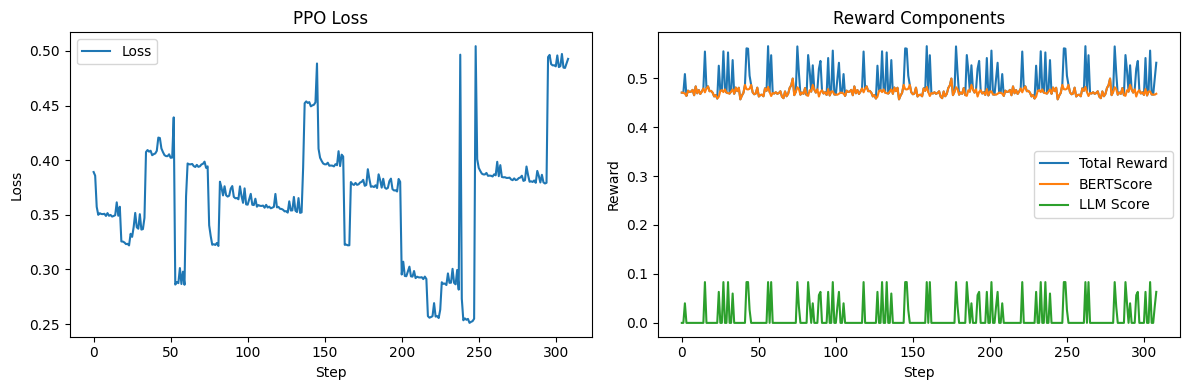

In [ ]:
import matplotlib.pyplot as plt

log_df = pd.read_csv('training_log.csv')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(log_df['step'], log_df['loss'], label='Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('PPO Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(log_df['step'], log_df['reward_total'], label='Total Reward')
plt.plot(log_df['step'], log_df['reward_bert'], label='BERTScore')
plt.plot(log_df['step'], log_df['reward_llm'], label='LLM Score')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward Components')
plt.legend()
plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

Сохранение LoRA-адаптера

In [ ]:
model.save_pretrained("./qwen_ppo_lora")
tokenizer.save_pretrained("./qwen_ppo_lora")
print("Модель сохранена в ./qwen_ppo_lora")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
save_path = '/content/drive/MyDrive/My Projects/model_ppo'

In [ ]:
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/My Projects/model_ppo/tokenizer_config.json',
 '/content/drive/MyDrive/My Projects/model_ppo/chat_template.jinja',
 '/content/drive/MyDrive/My Projects/model_ppo/tokenizer.json')

Оценка на тестовой выборке

In [ ]:
# ppo_test_dataset = prepare_ppo_dataset(test_dataset, tokenizer)

# # Извлекаем source_text и topic для теста
# test_source_texts = []
# test_topics = []
# for ex in test_dataset:
#     src, top = extract_source_and_topic(ex["input_text"])
#     test_source_texts.append(src)
#     test_topics.append(top)

# ppo_test_dataset = ppo_test_dataset.add_column("source_text", test_source_texts)
# ppo_test_dataset = ppo_test_dataset.add_column("topic", test_topics)

# device = next(model.parameters()).device

# predictions = []
# all_rewards_total = []
# all_rewards_bert = []
# all_rewards_llm = []

# for batch_idx, batch in enumerate(tqdm(ppo_test_dataset, desc="Evaluating on test")):
#     query = batch["query"]
#     target = batch["target"]
#     src = batch["source_text"]
#     topic = batch["topic"]

#     inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=512).to(device)
#     with torch.no_grad():
#         gen_ids = model.generate(
#             **inputs,
#             max_new_tokens=128,
#             do_sample=False,
#             pad_token_id=tokenizer.pad_token_id,
#         )
#     pred = tokenizer.decode(gen_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

#     # BERTScore
#     _, _, bert_f1 = bertscorer.score([pred], [target])
#     bert_reward = bert_f1.item()

#     # LLM score
#     if USE_LLM_REWARD:
#         new_llm = get_llm_score(pred, src, topic)
#         if new_llm is not None:
#             last_llm_score = new_llm
#         llm_reward = last_llm_score
#     else:
#         llm_reward = 0.0

#     total_reward = bert_reward + llm_reward

#     all_rewards_total.append(total_reward)
#     all_rewards_bert.append(bert_reward)
#     all_rewards_llm.append(llm_reward)

#     predictions.append({
#         "query": query,
#         "prediction": pred,
#         "target": target,
#         "source_text": src,
#         "topic": topic,
#         "reward_total": total_reward,
#         "reward_bert": bert_reward,
#         "reward_llm": llm_reward
#     })

# pred_df = pd.DataFrame(predictions)

# print("\n=== Test Metrics ===")
# print(f"Average Total Reward: {np.mean(all_rewards_total):.4f}")
# print(f"Average BERTScore: {np.mean(all_rewards_bert):.4f}")
# print(f"Average LLM Score: {np.mean(all_rewards_llm):.4f}")

# pred_df.to_csv('test_predictions.csv', index=False)
# print("\nPredictions saved to test_predictions.csv")
# pred_df.head()

Просмотр примера предсказания

In [ ]:
# print(pred_df.iloc[-1]["prediction"])

In [ ]:
for i in pred_df['prediction']:
    print(i, '\n', '*****************************************', '\n')